# **GTSRB Traffic Sign Recognition Notebook**

This notebook trains a Convolutional Neural Network (CNN) on the **German Traffic Sign Recognition Benchmark (GTSRB)** dataset.

---

### **Dataset Source**

The preprocessed traffic signs dataset is based on the **GTSRB** and is published on Kaggle by Valentyn Sichkar:  
[Kaggle Dataset: Traffic Signs Preprocessed] https://www.kaggle.com/datasets/valentynsichkar/traffic-signs-preprocessed

------

### **Dataset Setup**

This section prepares the environment and organizes the dataset:

- Upload Kaggle API credentials and configure access.  
- Download the preprocessed traffic signs dataset from Kaggle and extract it.  
- Verify that the dataset folders (`train`, `valid`, `test`) exist and contain class subfolders.  
- Mount Google Drive and create the project folder.  
- Move the extracted dataset to the project folder for faster access during training.
-----

##### **Upload Kaggle API credentials**


In [ ]:
from google.colab import files
# Upload kaggle.json file for Kaggle API authentication
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"yzhoo0608","key":"6a876f3f1d65bc04f4bf58f9ab67682d"}'}

##### **Set up Kaggle credentials**



In [ ]:
# Create .kaggle directory and move kaggle.json there
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

##### **Download the preprocessed traffic signs dataset from Kaggle**


In [ ]:
# Download the traffic signs preprocessed dataset from Kaggle
!kaggle datasets download -d valentynsichkar/traffic-signs-preprocessed

Dataset URL: https://www.kaggle.com/datasets/valentynsichkar/traffic-signs-preprocessed
License(s): other
 99% 4.12G/4.16G [01:28<00:00, 110MB/s] 
100% 4.16G/4.16G [01:28<00:00, 50.4MB/s]


##### **Extract the downloaded dataset**



In [ ]:
import zipfile
import os

# Define paths for the zip file and extraction folder
zip_path = '/content/traffic-signs-preprocessed.zip'
extract_path = '/content/traffic-signs-preprocessed'

# Extract the downloaded zip file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

##### **Check folders/files inside the dataset**



This code verifies that the `train`, `valid`, and `test` folders exist.

In [ ]:
# List all files in the folder
dataset_path = '/content/traffic-signs-preprocessed'
files = os.listdir(dataset_path)
print(f"Total files found: {len(files)}\n")

# Display all files with type and size
for f in files:
    full_path = os.path.join(dataset_path, f)
    if os.path.isfile(full_path):
        size_mb = os.path.getsize(full_path) / (1024*1024)
        print(f"{f} - Size: {size_mb:.2f} MB")
    elif os.path.isdir(full_path):
        print(f"{f} - Folder")

Total files found: 19

std_gray.pickle - Size: 0.00 MB
data6.pickle - Size: 407.04 MB
mean_image_gray.pickle - Size: 0.00 MB
data3.pickle - Size: 1219.77 MB
train.pickle - Size: 102.18 MB
data8.pickle - Size: 407.04 MB
data7.pickle - Size: 407.04 MB
data1.pickle - Size: 1219.77 MB
std_rgb.pickle - Size: 0.01 MB
test.pickle - Size: 37.09 MB
valid.pickle - Size: 12.95 MB
datasets_preparing.py - Size: 0.02 MB
data4.pickle - Size: 813.41 MB
data0.pickle - Size: 455.22 MB
mean_image_rgb.pickle - Size: 0.01 MB
label_names.csv - Size: 0.00 MB
data2.pickle - Size: 1219.77 MB
data5.pickle - Size: 407.04 MB
labels.pickle - Size: 0.00 MB


##### **Mount Google Drive**



In [ ]:
from google.colab import drive

# Mount Google Drive to save dataset permanently
drive.mount('/content/drive')

Mounted at /content/drive


##### **Set up project folder in Google Drive**


In [ ]:
import os

# Define project path in Google Drive
project_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project'
os.makedirs(project_path, exist_ok=True)

In [ ]:
# Move the extracted dataset to the project folder
!mv /content/traffic-signs-preprocessed $project_path/

---

##### **Dataset Preprocessing**

This section prepares the data for CNN training:

- Set random seeds for Python, NumPy, and TensorFlow to ensure reproducibility.  
- Normalize image pixel values to 0 to 1.  
- Resize images to 48×48 pixels.  
- Convert class labels to one-hot encoding for multi-class classification.  
- Load train, validation, and test datasets from pickle files.  
- Map class IDs to readable traffic sign names using `label_names.csv`.  
- Save test labels to a `.txt` file and verify the class distribution.
-------

##### **Import libraries**

In [ ]:
# -----------------------------
# Standard Python libraries
# ----------------------------
import os                 # File system operations
import random             # Random numbers & shuffling
import collections        # Data structures
import pickle             # Load pickled files
# -----------------------------
# Data manipulation & visualization
# -----------------------------
import numpy as np        # Numerical operations
import pandas as pd       # DataFrames & CSV handling
import matplotlib.pyplot as plt  # Plotting graphs and images
import seaborn as sns     # Visualization (heatmaps)

# -----------------------------
# Deep learning
# -----------------------------
import tensorflow as tf   # Deep learning framework
from tensorflow.keras.utils import to_categorical  # One-hot encoding
from tensorflow.keras.models import Sequential, load_model  # Build & load neural networks
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout  # CNN layers
from tensorflow.keras.preprocessing.image import load_img, img_to_array  # Image preprocessing
from tensorflow.keras.callbacks import EarlyStopping  # Stop training early if validation loss doesn't improve

# -----------------------------
# Model evaluation metrics
# -----------------------------
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [ ]:
# Set random seeds for reproducibility
seed_value = 42
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)

##### **Define Paths and Project Settings**




In [ ]:
# Define paths and project settings
dataset_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic-signs-preprocessed'  # raw dataset location
project_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project'  # folder to save results
os.makedirs(project_path, exist_ok=True)

image_size = (48, 48)
batch_size = 64
num_classes = 43

##### **Load Dataset**

This code defines the `load_dataset` function to read data from pickle files (`train.pickle`, `valid.pickle`, `test.pickle`).

- It normalizes image pixel values to the range 0 to 1.  
- It resizes all images to `48x48` pixels to match the CNN input size.  
- It converts class labels to one-hot encoding for multi-class classification.  

The function is then used to load the training (`train_x, train_y`), validation (`val_x, val_y`), and test (`test_x, test_y`) datasets for model training and evaluation.


In [ ]:
# ---------------------------
# Load dataset
# ---------------------------
def load_dataset(pickle_file):
    with open(os.path.join(dataset_path, pickle_file), 'rb') as f:
        data = pickle.load(f)
    # Normalize image pixels to 0 to 1
    images = np.array(data['features'], dtype='float32') / 255.0

    # Resize images
    images = tf.image.resize(images, image_size).numpy()

    # Convert labels to one-hot encoding
    labels = tf.keras.utils.to_categorical(data['labels'], num_classes)
    return images, labels

# Load train, validation, and test sets
train_x, train_y = load_dataset('train.pickle')
val_x, val_y = load_dataset('valid.pickle')
test_x, test_y = load_dataset('test.pickle')

##### **Dataset Summary and Test Set Analysis**


In [ ]:
# ---------------------------
# Print dataset shapes and label info
# ---------------------------
print("----Dataset summary:----")
print("Train images shape:", train_x.shape)
print("Train labels shape:", train_y.shape)
print("Validation images shape:", val_x.shape)
print("Validation labels shape:", val_y.shape)
print("Test images shape:", test_x.shape)
print("Test labels shape:", test_y.shape)

----Dataset summary:----
Train images shape: (34799, 48, 48, 3)
Train labels shape: (34799, 43)
Validation images shape: (4410, 48, 48, 3)
Validation labels shape: (4410, 43)
Test images shape: (12630, 48, 48, 3)
Test labels shape: (12630, 43)


In [ ]:
# Convert one-hot labels back to class indices
test_labels_classes = np.argmax(test_y, axis=1)

# Show all test labels
print("All test labels (class indices):")
print(test_labels_classes)

# Show total number of test samples
print(f"\nTotal test samples: {len(test_labels_classes)}")

All test labels (class indices):
[16  1 38 ...  6  7 10]

Total test samples: 12630


In [ ]:
# Save all test labels to a file
test_labels_file = os.path.join(project_path, 'test_labels.txt')
np.savetxt(test_labels_file, test_labels_classes, fmt='%d')
print(f"\nAll test labels saved to: {test_labels_file}")


All test labels saved to: /content/drive/MyDrive/GTSRB_Traffic_Sign_Project/test_labels.txt


In [ ]:
# -----------------------------
# Load label names from CSV
# -----------------------------
label_csv_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic-signs-preprocessed/label_names.csv'
label_names = pd.read_csv(label_csv_path)

# --- Create dictionary mapping ---
id_to_name = dict(zip(label_names['ClassId'], label_names['SignName']))

# --- Show all unique classes in the test set ---
print("\nAll Classes in Test Set:")
unique_classes = sorted(set(test_labels_classes))
for cid in unique_classes:
    cname = id_to_name.get(cid, "Unknown")
    print(f"Class {cid:>2}: {cname}")


All Classes in Test Set:
Class  0: Speed limit (20km/h)
Class  1: Speed limit (30km/h)
Class  2: Speed limit (50km/h)
Class  3: Speed limit (60km/h)
Class  4: Speed limit (70km/h)
Class  5: Speed limit (80km/h)
Class  6: End of speed limit (80km/h)
Class  7: Speed limit (100km/h)
Class  8: Speed limit (120km/h)
Class  9: No passing
Class 10: No passing for vehicles over 3.5 metric tons
Class 11: Right-of-way at the next intersection
Class 12: Priority road
Class 13: Yield
Class 14: Stop
Class 15: No vehicles
Class 16: Vehicles over 3.5 metric tons prohibited
Class 17: No entry
Class 18: General caution
Class 19: Dangerous curve to the left
Class 20: Dangerous curve to the right
Class 21: Double curve
Class 22: Bumpy road
Class 23: Slippery road
Class 24: Road narrows on the right
Class 25: Road work
Class 26: Traffic signals
Class 27: Pedestrians
Class 28: Children crossing
Class 29: Bicycles crossing
Class 30: Beware of ice/snow
Class 31: Wild animals crossing
Class 32: End of all sp

In [ ]:
# Class distribution in test set
label_counts = collections.Counter(test_labels_classes)
print("\nTest label distribution (class count):")
for cls, count in sorted(label_counts.items()):
    print(f"Class {cls}: {count}")


Test label distribution (class count):
Class 0: 60
Class 1: 720
Class 2: 750
Class 3: 450
Class 4: 660
Class 5: 630
Class 6: 150
Class 7: 450
Class 8: 450
Class 9: 480
Class 10: 660
Class 11: 420
Class 12: 690
Class 13: 720
Class 14: 270
Class 15: 210
Class 16: 150
Class 17: 360
Class 18: 390
Class 19: 60
Class 20: 90
Class 21: 90
Class 22: 120
Class 23: 150
Class 24: 90
Class 25: 480
Class 26: 180
Class 27: 60
Class 28: 150
Class 29: 90
Class 30: 150
Class 31: 270
Class 32: 60
Class 33: 210
Class 34: 120
Class 35: 390
Class 36: 120
Class 37: 60
Class 38: 690
Class 39: 90
Class 40: 90
Class 41: 60
Class 42: 90


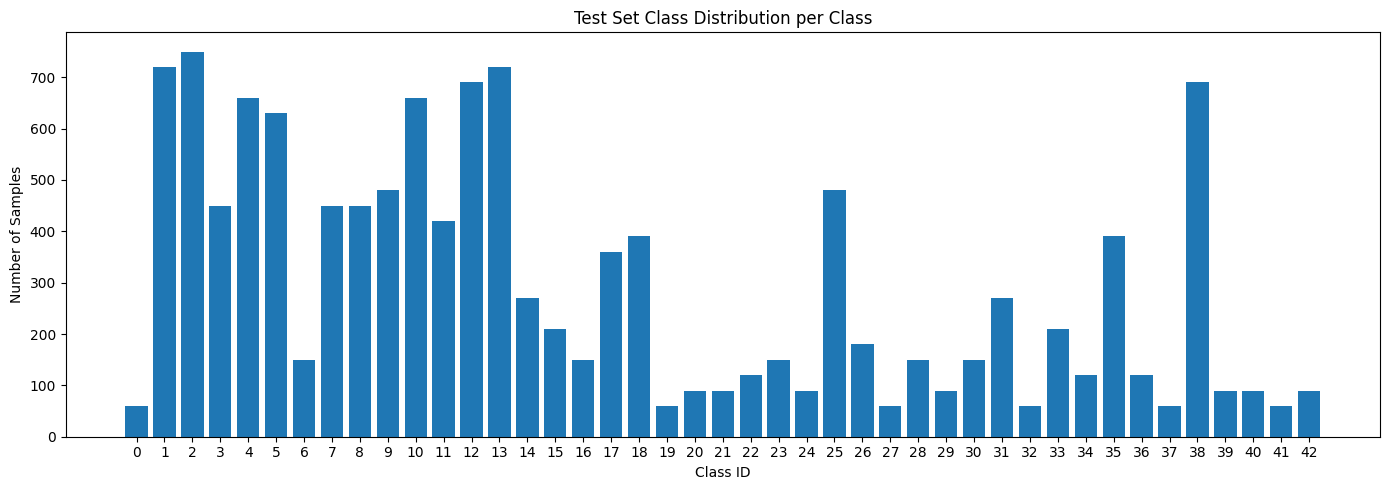

In [ ]:
# Plot class distribution in test set
plt.figure(figsize=(14,5))
plt.bar(range(num_classes), [label_counts[i] for i in range(num_classes)])
plt.xticks(range(num_classes))  # Only class IDs
plt.xlabel('Class ID')
plt.ylabel('Number of Samples')
plt.title('Test Set Class Distribution per Class')
plt.tight_layout()
plt.show()


##### **CNN Model**

This code builds a CNN for traffic sign classification:

- 3 convolutional layers (32, 64, 128 filters) and each followed by MaxPooling.  
- Flatten → Dense(128) → Dropout(0.5) → Output layer with softmax.  



In [ ]:
# ---------------------------
# Define CNN model
# ---------------------------
model = Sequential([
    # Convolutional layer 1: 32 filters, 3x3 kernel, ReLU activation
    # input_shape specifies 48x48 RGB images
    Conv2D(32, (3,3), activation='relu', input_shape=(48,48,3)),
    MaxPooling2D(2,2), # Max pooling layer 1: Reduce spatial dimensions by half

    # Convolutional layer 2: 64 filters, 3x3 kernel, ReLU activation
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2), # MaxPooling layer 2: further downsample feature maps


    # Convolutional layer 3: 128 filters, 3x3 kernel, ReLU activation
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2), # MaxPooling layer 3: Reduce spatial size while keeping important features



    # Flatten 3D feature maps to 1D vector for fully connected layers
    Flatten(),
    Dense(128, activation='relu'),  # Fully connected layer with 128 units
    Dropout(0.5),  # Dropout to reduce overfitting (randomly drop 50% neurons)
    Dense(num_classes, activation='softmax') # Output layer for classification
])

# Compile the model
model.compile(
    optimizer='adam',                # Adam optimizer with adaptive learning rate
    loss='categorical_crossentropy', # Multi-class classification loss
    metrics=['accuracy']             # Track accuracy during training
)

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 46, 46, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 23, 23, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 21, 21, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 10, 10, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 43)             │         5,547 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 361,067 (1.38 MB)

 Trainable params: 361,067 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

##### **Train the model & results**


In [ ]:
# ---------------------------
# Define EarlyStopping callback
# ---------------------------
early_stop = EarlyStopping(
    monitor='val_loss',        # Monitor validation loss
    patience=5,                # Stop if no improvement for 5 epochs
    restore_best_weights=True  # Restore model weights from the epoch with the best val_loss
)

# ---------------------------
# Train model with EarlyStopping
# ---------------------------
history = model.fit(
    train_x,                        # Training images
    train_y,                        # Training labels
    validation_data=(val_x, val_y), # Validation data for monitoring performance
    epochs=20,
    batch_size=batch_size,          # Batch size
    shuffle=True,                   # Shuffle data each epoch
    callbacks=[early_stop]          # add early stopping here
)

Epoch 1/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 140s 253ms/step - accuracy: 0.2639 - loss: 2.7218 - val_accuracy: 0.8295 - val_loss: 0.6084
Epoch 2/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 139s 256ms/step - accuracy: 0.8047 - loss: 0.6228 - val_accuracy: 0.9227 - val_loss: 0.2948
Epoch 3/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 133s 240ms/step - accuracy: 0.9018 - loss: 0.3148 - val_accuracy: 0.9449 - val_loss: 0.1827
Epoch 4/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 139s 235ms/step - accuracy: 0.9301 - loss: 0.2190 - val_accuracy: 0.9565 - val_loss: 0.1569
Epoch 5/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 128s 235ms/step - accuracy: 0.9502 - loss: 0.1600 - val_accuracy: 0.9664 - val_loss: 0.1267
Epoch 6/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 142s 236ms/step - accuracy: 0.9588 - loss: 0.1252 - val_accuracy: 0.9601 - val_loss: 0.1468
Epoch 7/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 141s 234ms/step - accuracy: 0.9671 - loss: 0.1027 - val_accuracy: 0.9694 - val_loss: 0.1219
Epoch 8/20
544/544 ━━━━━━━━━━━━━━━━━━━━ 142s 234ms/step - accuracy: 0.9706 -

##### **Save Trained Model**

This code saves the trained CNN in two formats:

- **Keras native format (`.keras`)**  
- **HDF5 format (`.h5`)**  

Both files are stored in the project folder so that if one format cannot be loaded, the other can be used.

In [ ]:
# ---------------------------
# Save trained model (native Keras format)
# ---------------------------
model_save_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic_sign_cnn.keras'
model.save(model_save_path)
print(f"Model saved in native Keras format to: {model_save_path}")


Model saved in native Keras format to: /content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic_sign_cnn.keras


In [ ]:
# ---------------------------
# Save trained model as HDF5
# ---------------------------

model_save_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic_sign_cnn.h5'
model.save(model_save_path)
print(f"Model saved as HDF5 to: {model_save_path}")


Model saved as HDF5 to: /content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic_sign_cnn.h5


##### **Training and Validation Accuracy & Loss Curves**


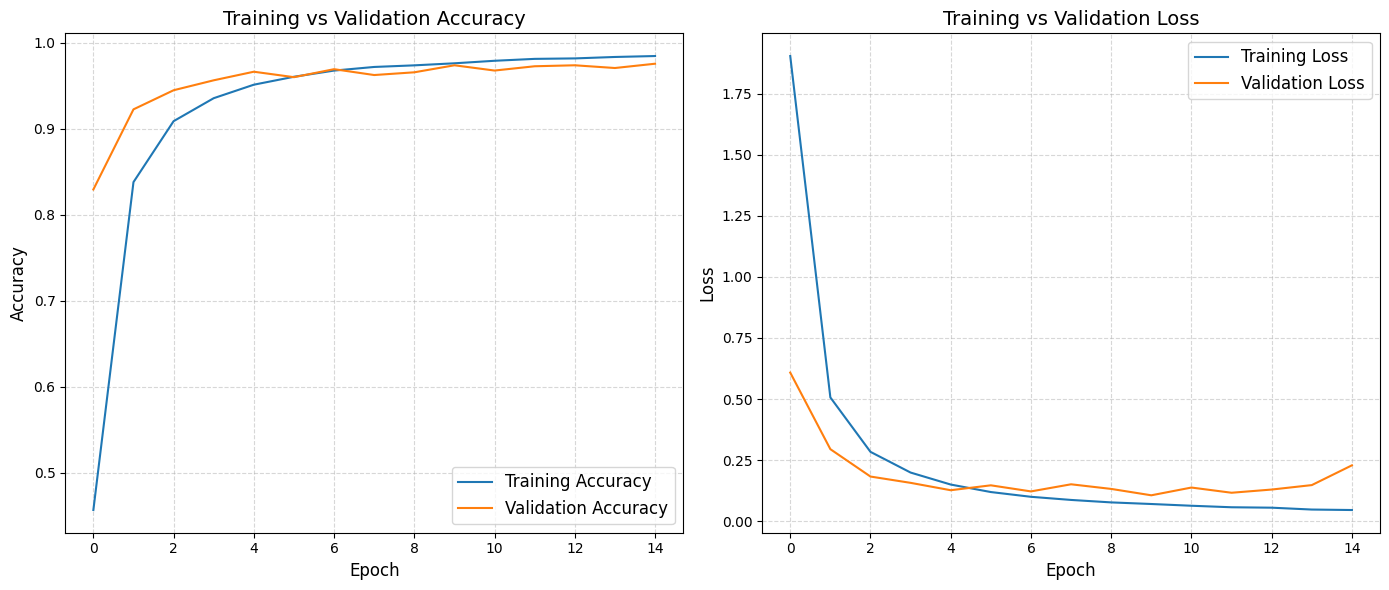

In [ ]:

# ---------------------------
# Plot training and validation accuracy and loss
# ---------------------------
plt.figure(figsize=(14,6))

# Subplot 1: Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')       # Plot training accuracy over epochs
plt.plot(history.history['val_accuracy'], label='Validation Accuracy') # Plot validation accuracy over epochs
plt.title('Training vs Validation Accuracy', fontsize=14) # Subplot title
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# Subplot 2: Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')       # Plot training loss over epochs
plt.plot(history.history['val_loss'], label='Validation Loss') # Plot validation loss over epochs
plt.title('Training vs Validation Loss', fontsize=14) # Subplot title
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout() # Adjust subplots to prevent overlap of titles/labels
plt.show()         # Display the figure


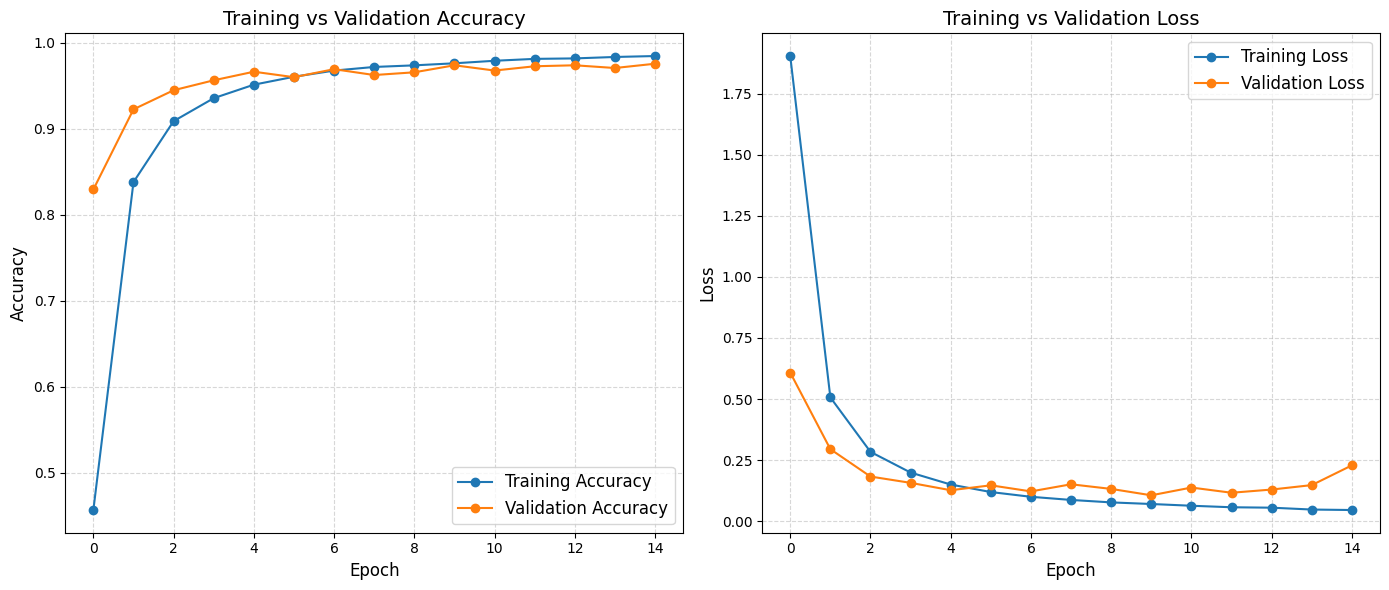

In [ ]:
plt.figure(figsize=(14,6))

# Subplot 1: Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

# Subplot 2: Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=12)

plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------
# Make predictions on the test set
# ---------------------------
y_pred = model.predict(test_x, batch_size=batch_size)  # Predict probabilities for each class
y_pred_classes = np.argmax(y_pred, axis=1)             # Convert predicted probabilities to class indices
y_true = np.argmax(test_y, axis=1)                     # True class indices from one-hot labels



198/198 ━━━━━━━━━━━━━━━━━━━━ 18s 88ms/step


In [ ]:
# ---Evaluate the model on the test set---
test_loss, test_accuracy = model.evaluate(test_x, test_y)

# ---Print the results---
print(f"Test Accuracy: {test_accuracy:.4f}, Test Loss: {test_loss:.4f}")

395/395 ━━━━━━━━━━━━━━━━━━━━ 15s 38ms/step - accuracy: 0.9597 - loss: 0.1940
Test Accuracy: 0.9582, Test Loss: 0.2137


In [ ]:
# Print classification metrics
acc = accuracy_score(y_true, y_pred_classes)
print("Test Accuracy: {:.2f}%\n".format(acc * 100))

Test Accuracy: 95.82%



##### **Confusion Matrix**


198/198 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step


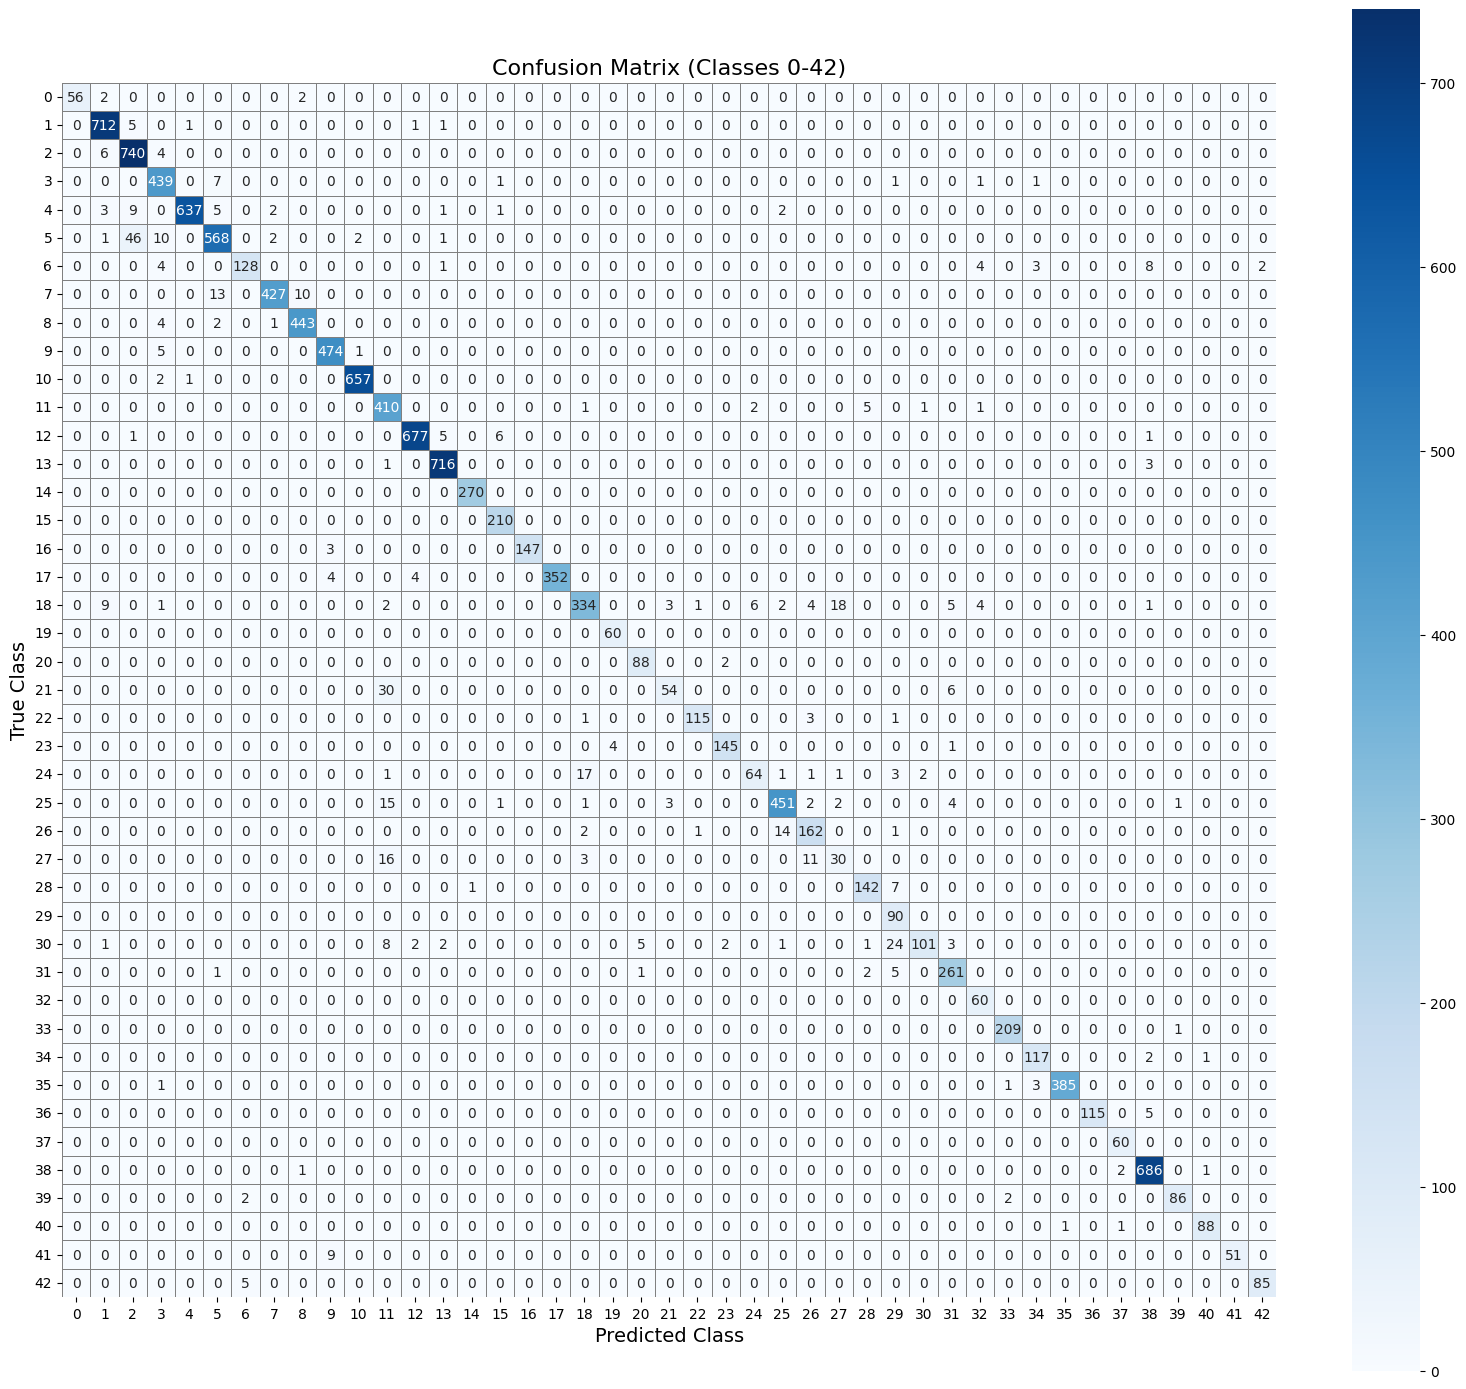

In [ ]:
# ---------------------------
# Confusion Matrix
# ---------------------------

# Predict classes for the test set
y_pred = model.predict(test_x, batch_size=batch_size) # Get predicted probabilities
y_pred_classes = np.argmax(y_pred, axis=1)            # Convert to class indices
y_true = np.argmax(test_y, axis=1)                    # True class indices from one-hot labels

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred_classes) # Rows = true classes, Columns = predicted classes

# Plot confusion matrix
plt.figure(figsize=(16,14))
sns.heatmap(
    cm,
    annot=True,   # Show numbers in each cell
    fmt='d',      # Integer format
    cmap='Blues', # Color map
    xticklabels=[str(i) for i in range(43)], # X-axis: class IDs 0-42
    yticklabels=[str(i) for i in range(43)], # Y-axis: class IDs 0-42
    square=True,      # Make cells square
    cbar=True,        # Show color bar
    linewidths=0.5,   # Line width between cells
    linecolor='gray'  # Line color
)
plt.xlabel('Predicted Class', fontsize=14) # X-axis label
plt.ylabel('True Class', fontsize=14)     # Y-axis label
plt.title('Confusion Matrix (Classes 0-42)', fontsize=16) # Title
plt.xticks(rotation=0) # Keep x-axis labels horizontal
plt.yticks(rotation=0) # Keep y-axis labels horizontal
plt.tight_layout()  # Adjust layout
plt.show() # Display the confusion matrix plot

##### **Classification report**


In [ ]:
# ---------------------------
# Classification Report (Accuracy, Precision, Recall, F1)
# ---------------------------

# Detailed classification report
class_report = classification_report(
    y_true,
    y_pred_classes,
    target_names=[f'Class {i}' for i in range(43)]
)
print("Classification Report:\n")
print(class_report)


Classification Report:

              precision    recall  f1-score   support

     Class 0       1.00      0.93      0.97        60
     Class 1       0.97      0.99      0.98       720
     Class 2       0.92      0.99      0.95       750
     Class 3       0.93      0.98      0.95       450
     Class 4       1.00      0.97      0.98       660
     Class 5       0.95      0.90      0.93       630
     Class 6       0.95      0.85      0.90       150
     Class 7       0.99      0.95      0.97       450
     Class 8       0.97      0.98      0.98       450
     Class 9       0.97      0.99      0.98       480
    Class 10       1.00      1.00      1.00       660
    Class 11       0.85      0.98      0.91       420
    Class 12       0.99      0.98      0.99       690
    Class 13       0.98      0.99      0.99       720
    Class 14       1.00      1.00      1.00       270
    Class 15       0.96      1.00      0.98       210
    Class 16       1.00      0.98      0.99       150
   

##### **Misclassification only confusion matrix**


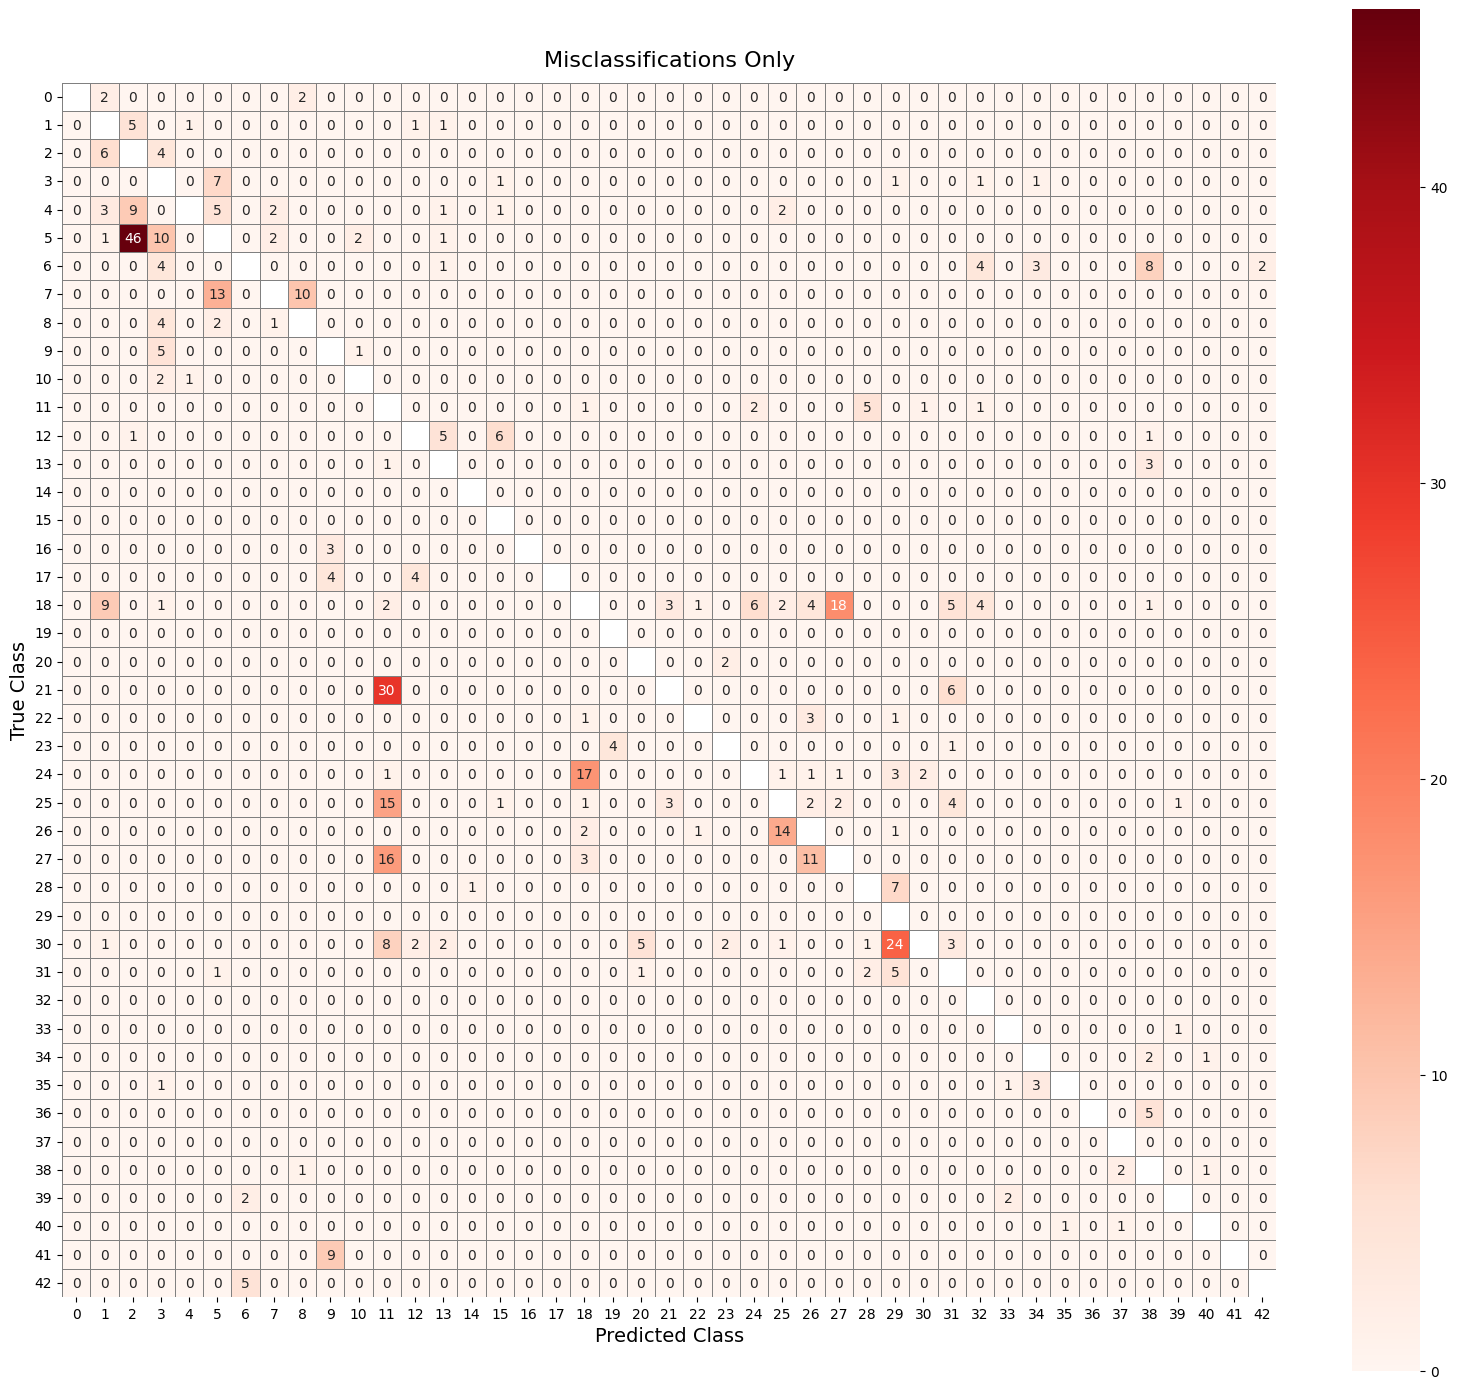

In [ ]:
# ---------------------------
# Plot misclassifications only
# ---------------------------

# Create a mask for the diagonal (correct predictions)
# True = hide cell, False = show cell
# Diagonal represents correct predictions, so masking it highlights only errors
mask = np.eye(cm.shape[0], dtype=bool)

plt.figure(figsize=(16, 14))
sns.heatmap(
    cm,
    annot=True,  # Show numbers in each cell
    fmt='d',     # Display numbers as integers
    cmap='Reds', # Use red color scale for misclassifications
    xticklabels=[str(i) for i in range(43)],  # X-axis class IDs
    yticklabels=[str(i) for i in range(43)], # Y-axis class IDs
    mask=mask,  # Mask diagonal to show only misclassifications
    square=True,
    linewidths=0.5,
    linecolor='gray',
    cbar=True
)
plt.title('Misclassifications Only', fontsize=16, pad=12)
plt.xlabel('Predicted Class', fontsize=14)
plt.ylabel('True Class', fontsize=14)
plt.xticks(rotation=0)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [ ]:
# ---------------------------
# Compute total misclassifications per class
# ---------------------------
misclass_per_class = cm.sum(axis=1) - np.diag(cm)  # sum of row minus diagonal

# Print misclassifications per class
print("---- Misclassifications per Class ----")
for i, count in enumerate(misclass_per_class):
    class_name = id_to_name.get(i, f"Class {i}") # Get class name from dictionary
    print(f"Class {i} ({class_name}): {count}")

---- Misclassifications per Class ----
Class 0 (Speed limit (20km/h)): 4
Class 1 (Speed limit (30km/h)): 8
Class 2 (Speed limit (50km/h)): 10
Class 3 (Speed limit (60km/h)): 11
Class 4 (Speed limit (70km/h)): 23
Class 5 (Speed limit (80km/h)): 62
Class 6 (End of speed limit (80km/h)): 22
Class 7 (Speed limit (100km/h)): 23
Class 8 (Speed limit (120km/h)): 7
Class 9 (No passing): 6
Class 10 (No passing for vehicles over 3.5 metric tons): 3
Class 11 (Right-of-way at the next intersection): 10
Class 12 (Priority road): 13
Class 13 (Yield): 4
Class 14 (Stop): 0
Class 15 (No vehicles): 0
Class 16 (Vehicles over 3.5 metric tons prohibited): 3
Class 17 (No entry): 8
Class 18 (General caution): 56
Class 19 (Dangerous curve to the left): 0
Class 20 (Dangerous curve to the right): 2
Class 21 (Double curve): 36
Class 22 (Bumpy road): 5
Class 23 (Slippery road): 5
Class 24 (Road narrows on the right): 26
Class 25 (Road work): 29
Class 26 (Traffic signals): 18
Class 27 (Pedestrians): 30
Class 28 (C

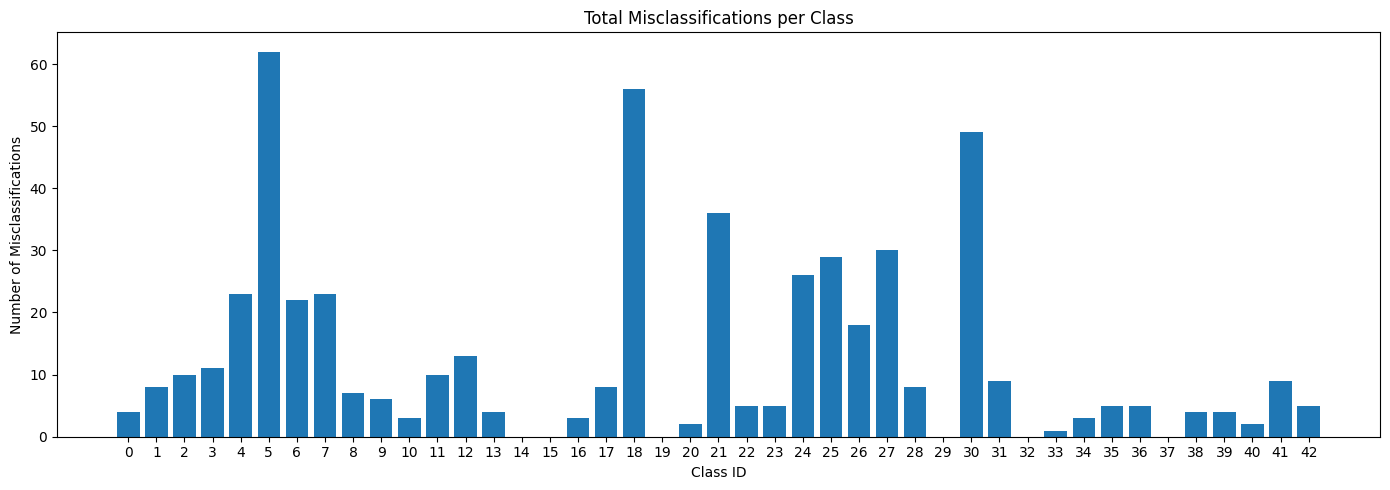

In [ ]:
# ---------------------------
# Plot misclassifications per class
# ---------------------------
plt.figure(figsize=(14,5))
plt.bar(range(43), misclass_per_class)  # Bar chart: x = class ID, y = number of misclassifications
plt.xticks(range(43))  # Only class IDs on x-axis
plt.xlabel('Class ID')
plt.ylabel('Number of Misclassifications')
plt.title('Total Misclassifications per Class')
plt.tight_layout()
plt.show()

##### **Predict classes for Test Images**


198/198 ━━━━━━━━━━━━━━━━━━━━ 17s 84ms/step


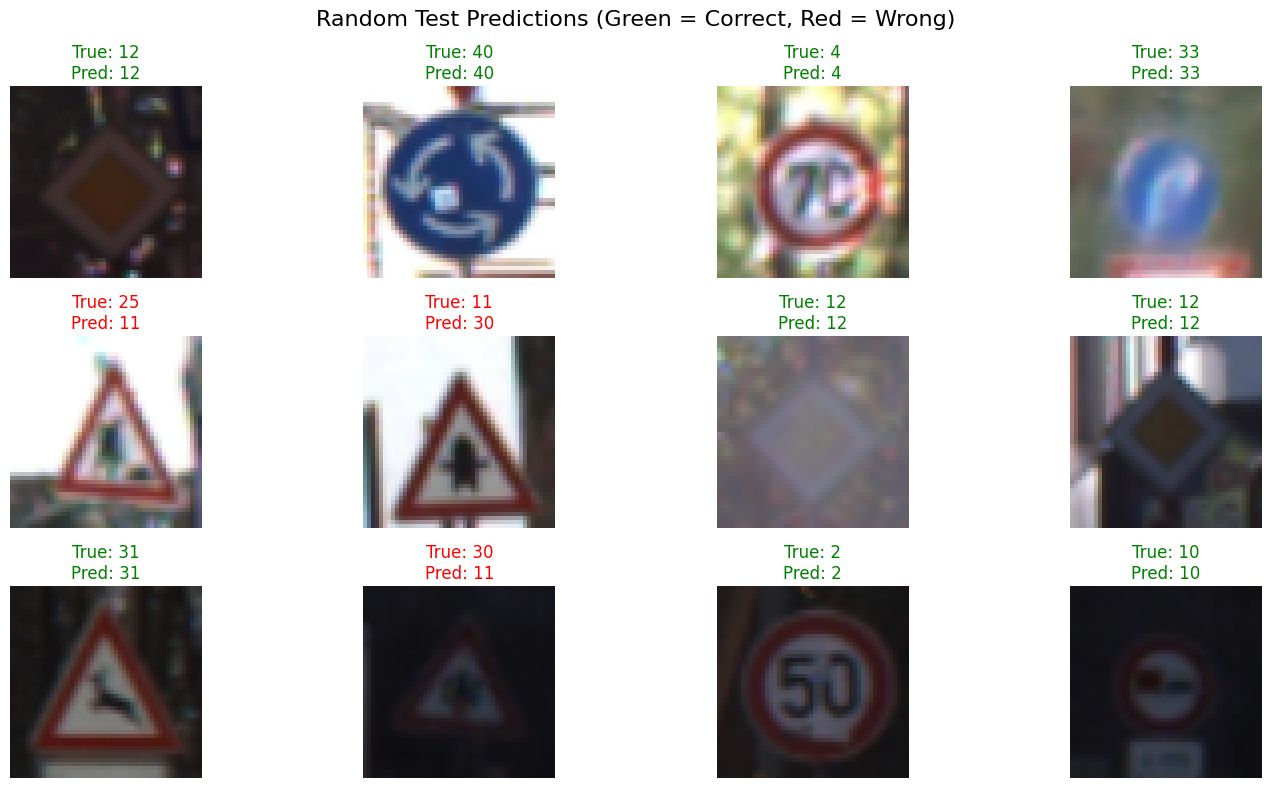

In [ ]:
# ---------------------------
# Visualize random test samples with predictions
# ---------------------------
# Predict class probabilities for the test set （batch size=64)
y_pred = model.predict(test_x, batch_size=64)
y_pred_classes = np.argmax(y_pred, axis=1)  # Convert probabilities to class indices
y_true = np.argmax(test_y, axis=1)          # True class indices from one-hot labels

# Randomly select 12 samples from the test set
num_samples = 12
indices = np.random.choice(len(test_x), num_samples, replace=False) # Random indices without replacement

# Get the images and their true/predicted labels
sample_images = test_x[indices]       # Get the images at these indices
sample_true = y_true[indices]         # True labels
sample_pred = y_pred_classes[indices] # Predicted labels

# Plot 12 random test samples
plt.figure(figsize=(15, 8))      # Figure size: 3 rows x 4 column
for i in range(num_samples):
    plt.subplot(3, 4, i + 1)     # 3 rows, 4 columns, subplot index
    plt.imshow(sample_images[i]) # Display image
    plt.axis('off')              # Hide axes
    color = 'green' if sample_true[i] == sample_pred[i] else 'red' # Green if correct, red if wrong
    plt.title(f"True: {sample_true[i]}\nPred: {sample_pred[i]}", # Show true and predicted class
              color=color, fontsize=12)

plt.suptitle("Random Test Predictions (Green = Correct, Red = Wrong)", fontsize=16)
plt.tight_layout() # Adjust subplots to prevent overlap
plt.show()         # Display the figure

##### **Visualize CNN Filters and Feature Maps**

This section demonstrates how the trained CNN processes images:

1. **Load Test Image and Model:**  
  - Loads the trained model (`.h5`) and test dataset.  
   - Selects a sample image and displays it with its class ID and name.

2. **Visualize Convolutional Filters:**  
  - Extracts all convolutional layers from the model.  
  - Displays the first 9 filters of each conv layer to show what patterns the network learns.

3. **Visualize Feature Maps:**  
  - Creates a model that outputs activations of all conv layers.  
- Passes the sample image through this model.  
 - Displays the first 9 feature maps for each conv layer to show how the network transforms the input image at each layer.


Model loaded successfully!


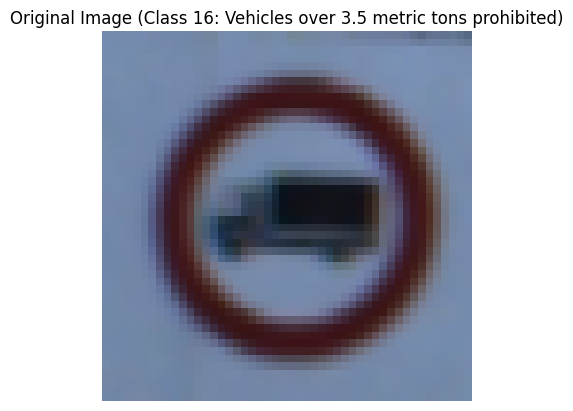

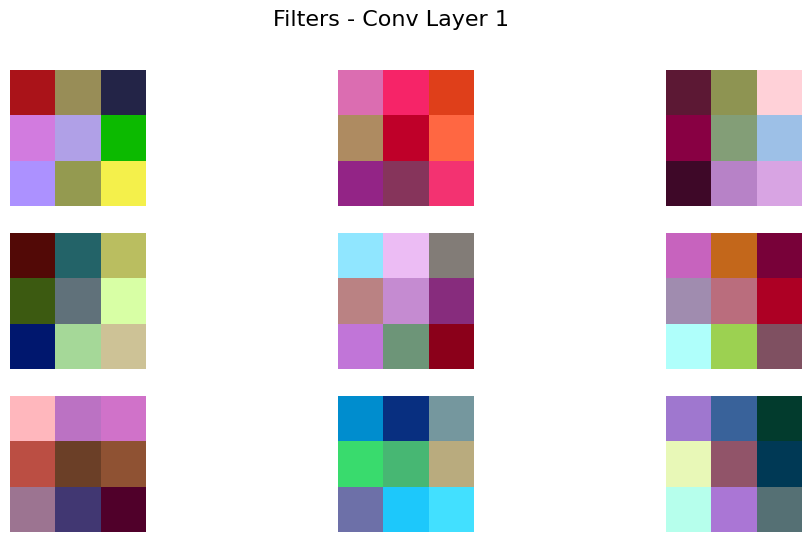

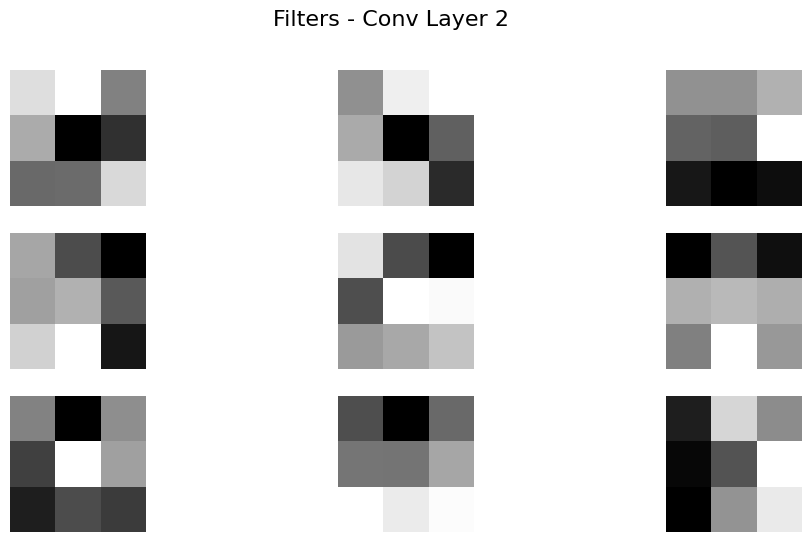

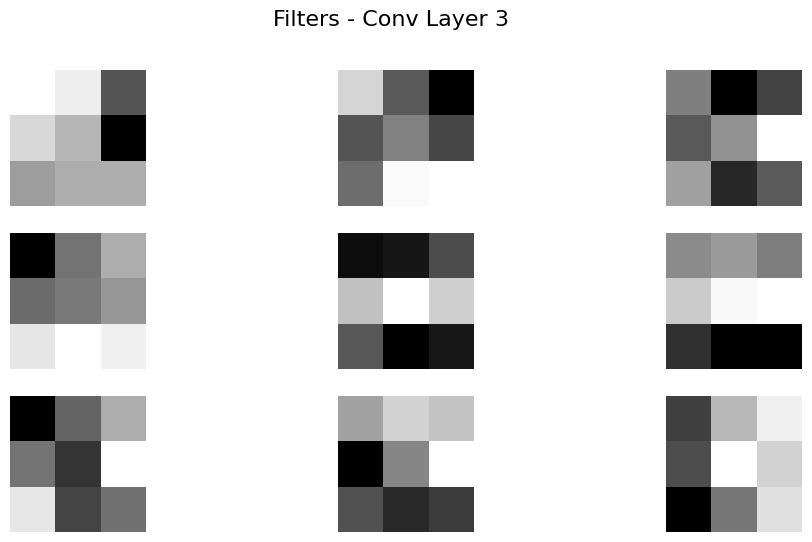

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step


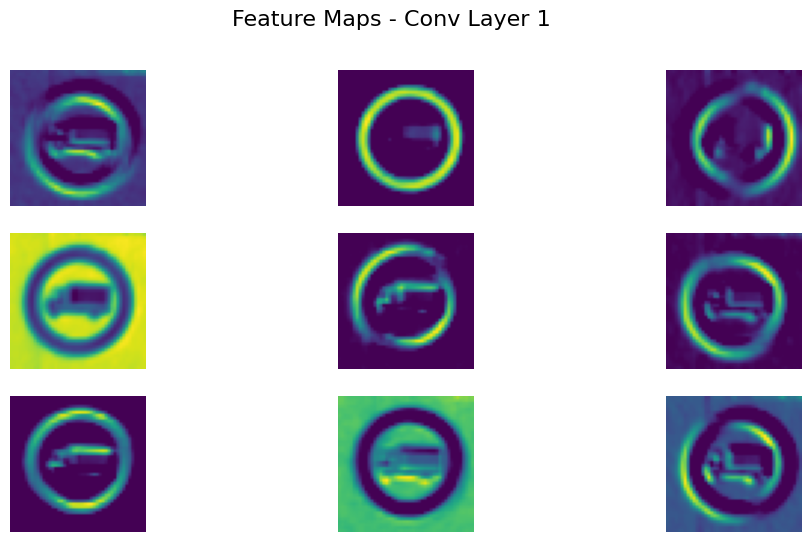

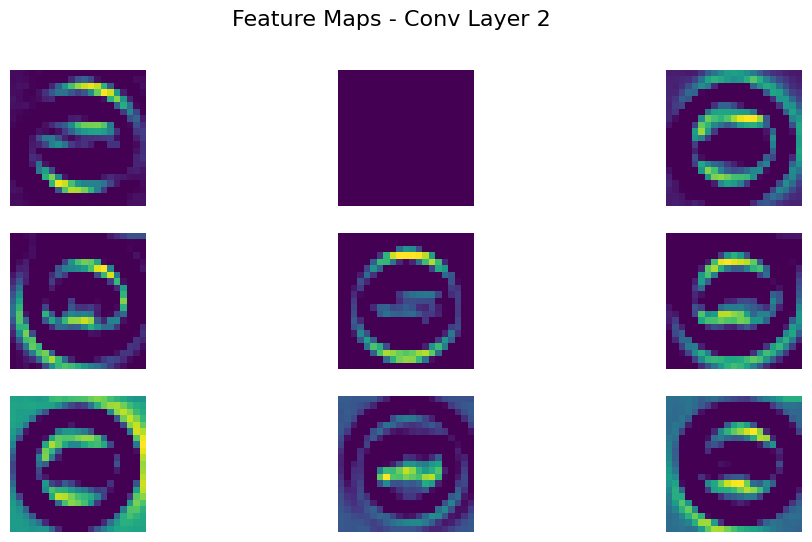

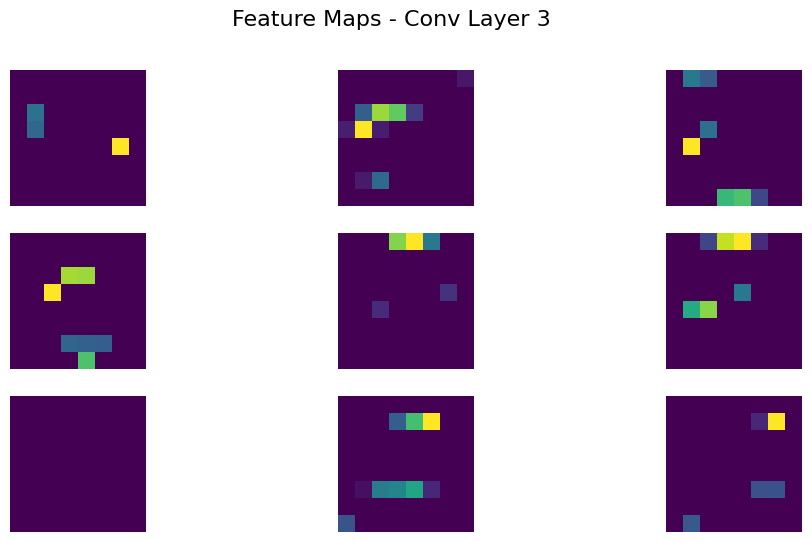

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import Model, load_model # Import load_model
import pickle
import os
import pandas as pd
import tensorflow as tf


# ---------------------------
# Load dataset
# ---------------------------
dataset_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic-signs-preprocessed'
image_size = (48, 48)
num_classes = 43

def load_dataset(pickle_file):
    with open(os.path.join(dataset_path, pickle_file), 'rb') as f:
        data = pickle.load(f)
    images = np.array(data['features'], dtype='float32') / 255.0
    images = tf.image.resize(images, image_size).numpy()
    labels = tf.keras.utils.to_categorical(data['labels'], num_classes)
    return images, labels

# Load test set
test_x, test_y = load_dataset('test.pickle')
# ---------------------------

# ---------------------------
# Load label names from CSV
# ---------------------------
label_csv_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic-signs-preprocessed/label_names.csv'
label_names = pd.read_csv(label_csv_path)
id_to_name = dict(zip(label_names['ClassId'], label_names['SignName']))
# ---------------------------

# ---------------------------
#  Load Trained Model
# ---------------------------
model_path = '/content/drive/MyDrive/GTSRB_Traffic_Sign_Project/traffic_sign_cnn.h5'
model = load_model(model_path)
print("Model loaded successfully!")
# ---------------------------


# ---------------------------
# Prepare a sample image
# ---------------------------
sample_img = test_x[0]  # pick the first test image
sample_img_expanded = np.expand_dims(sample_img, axis=0) # add batch dimension

# Get the class ID and name
cid = np.argmax(test_y[0])  # class ID
class_name = id_to_name[cid]  # name

# ---------------------------
#  Display the sample image with class ID and name
# ---------------------------
plt.imshow(sample_img)
plt.title(f"Original Image (Class {cid}: {class_name})")
plt.axis('off')
plt.show()

# ---------------------------
#  Get all Conv layers
# ---------------------------
conv_layers = [layer for layer in model.layers if 'conv' in layer.name]

# ---------------------------
# Visualize filters for all Conv layers
# ---------------------------
for layer_idx, layer in enumerate(conv_layers, start=1):
    # Get weights (filters) and biases
    weights, biases = layer.get_weights()
    num_filters = weights.shape[-1]

    plt.figure(figsize=(12,6))
    for filter_idx in range(min(9, num_filters)):  # first 9 filters
        f = weights[:,:,:,filter_idx]
        f = (f - f.min()) / (f.max() - f.min())  # normalize
        plt.subplot(3,3,filter_idx+1)
        if weights.shape[2] == 3:  # RGB input
            plt.imshow(f)
        else:  # grayscale
            plt.imshow(f[:,:,0], cmap='gray')
        plt.axis('off')
    plt.suptitle(f"Filters - Conv Layer {layer_idx}", fontsize=16)
    plt.show()

# ---------------------------
#  Create activation model for all Conv layers
# ---------------------------
layer_outputs = [layer.output for layer in conv_layers]
activation_model = Model(inputs=model.layers[0].input, outputs=layer_outputs)

# ---------------------------
# Get feature maps for the sample image
# ---------------------------
feature_maps = activation_model.predict(sample_img_expanded)

# ---------------------------
#  Visualize feature maps for all Conv layers
# ---------------------------
for layer_idx, fmap in enumerate(feature_maps, start=1):
    num_features = fmap.shape[-1]
    plt.figure(figsize=(12,6))
    for feature_idx in range(min(9, num_features)):  # first 9 feature maps
        plt.subplot(3,3,feature_idx+1)
        plt.imshow(fmap[0,:,:,feature_idx], cmap='viridis')
        plt.axis('off')
    plt.suptitle(f"Feature Maps - Conv Layer {layer_idx}", fontsize=16)
    plt.show()